# Modelo para Classificação da Qualidade de Vinhos
### TechChallenge - Fase 2 - Data Analytics 2026

#### **Aluno**: Bruno Ricardo de Oliveira - Grupo: 143

***Objetivo***: Desenvolver modelos de classificação capaz de prever a qualidade de vinhos com base em variáveis físico-químicas.


#### Base de Dados a ser analisada para modelagem dos modelos

O Data Frame contém as seguintes colunas:

Input variables (based on physicochemical tests):\
1 - fixed acidity\
2 - volatile acidity\
3 - citric acid\
4 - residual sugar\
5 - chlorides\
6 - free sulfur dioxide\
7 - total sulfur dioxide\
8 - density\
9 - pH\
10 - sulphates\
11 - alcohol\
Output variable (based on sensory data):\
12 - quality (score between 0 and 10)

Em resumo, a base contém atributos físico-químicos como acidez fixa, acidez volátil, ácido cítrico, açúcar residual, cloretos, dióxido de enxofre, densidade, pH, sulfatos, álcool e a nota  quality.

#### Instalação das Bibliotecas

In [31]:
from pathlib import Path
import subprocess
import sys

# encontrando o requirements.txt
requirements_file = next(
    (parent / "requirements.txt" for parent in [Path.cwd(), *Path.cwd().parents] if (parent / "requirements.txt").exists()),
    None,
)

if requirements_file is None:
    raise FileNotFoundError("requirements.txt não encontrado. Abra o notebook dentro do repositório clonado.")

subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(requirements_file)])
print(f"Dependências instaladas a partir de: {requirements_file}")

Dependências instaladas a partir de: /Users/brunoricardo/Documents/Cursos/POSTECH FIAP - DATA ANALYTICS/FASE 2/TECH CHALLENGE/wine-quality-classification/requirements.txt


#### Importação das Bibliotecas para Análise

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from pathlib import Path

#### Configurações

In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)


#### Importando a Base de Dados

In [7]:
data_path = Path("../data/WineQT.csv")
df = pd.read_csv(data_path)

## EDA - ANÁLISE ESPLORATÓRIA DOS DADOS

### Verificações Iniciais da Base

In [18]:
print(f"Shape da base (Quantidade de linhas, Quantidade de colunas): {df.shape}")

print("Primeiras linhas da base de dados e seus valores:")
df.head()

Shape da base (Quantidade de linhas, Quantidade de colunas): (1143, 13)
Primeiras linhas da base de dados e seus valores:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,0
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5,1
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5,2
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6,3
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,4


In [19]:
print("Ordem das Colunas da Base de Dados:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

Ordem das Colunas da Base de Dados:
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
12. quality
13. Id


#### Tipos de Dados e Valores não Nulos

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


#### Estatística Descritiva

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0000,8.3111,1.7476,4.6000,7.1000,7.9000,9.1000,15.9000
volatile acidity,1143.0000,0.5313,0.1796,0.1200,0.3925,0.5200,0.6400,1.5800
citric acid,1143.0000,0.2684,0.1967,0.0000,0.0900,0.2500,0.4200,1.0000
residual sugar,1143.0000,2.5322,1.3559,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,1143.0000,0.0869,0.0473,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,1143.0000,15.6155,10.2505,1.0000,7.0000,13.0000,21.0000,68.0000
total sulfur dioxide,1143.0000,45.9147,32.7821,6.0000,21.0000,37.0000,61.0000,289.0000
density,1143.0000,0.9967,0.0019,0.9901,0.9956,0.9967,0.9978,1.0037
pH,1143.0000,3.3110,0.1567,2.7400,3.2050,3.3100,3.4000,4.0100
sulphates,1143.0000,0.6577,0.1704,0.3300,0.5500,0.6200,0.7300,2.0000


#### Verificando Valores Ausentes na Base

In [23]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]


Series([], dtype: int64)

<Axes: >

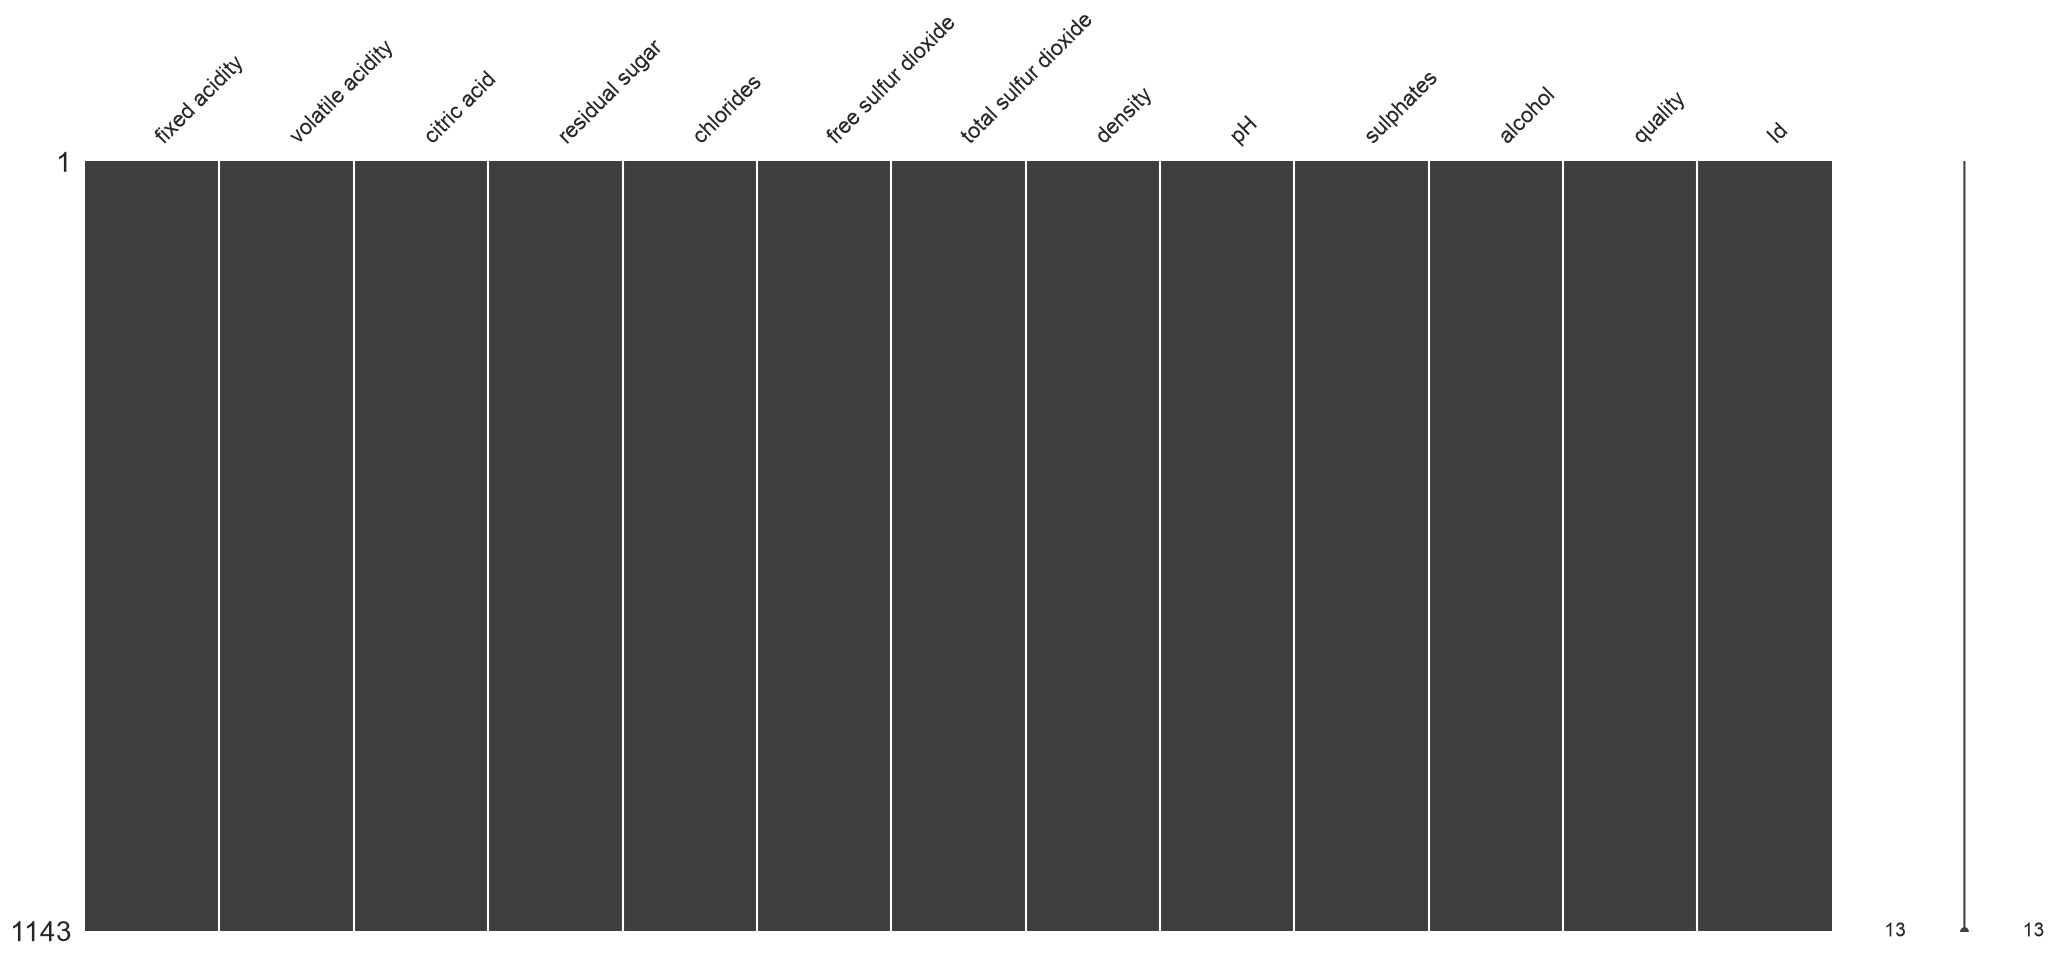

In [34]:
msno.matrix(df)

#### Verificação de Valores Duplicados

In [25]:
#### Verificação de Valores Duplicados
duplicate_values = df.duplicated().sum()
print(f"Quantidade de valores duplicados: {duplicate_values}")

Quantidade de valores duplicados: 0


#### Avaliando a Distribuição da Qualidade da Base

Distribuição da qualidade original da base de dados:


quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

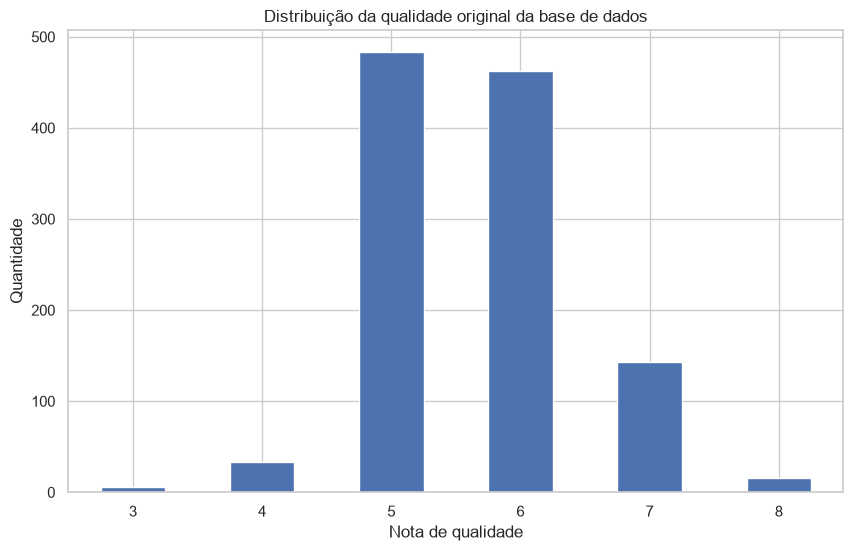

In [27]:
quality_counts = df["quality"].value_counts().sort_index()
print("Distribuição da qualidade original da base de dados:")
display(quality_counts)

ax = quality_counts.plot(kind="bar")
ax.set_title("Distribuição da qualidade original da base de dados")
ax.set_xlabel("Nota de qualidade")
ax.set_ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

#### Analisando a distribuição de cada Variável Característica

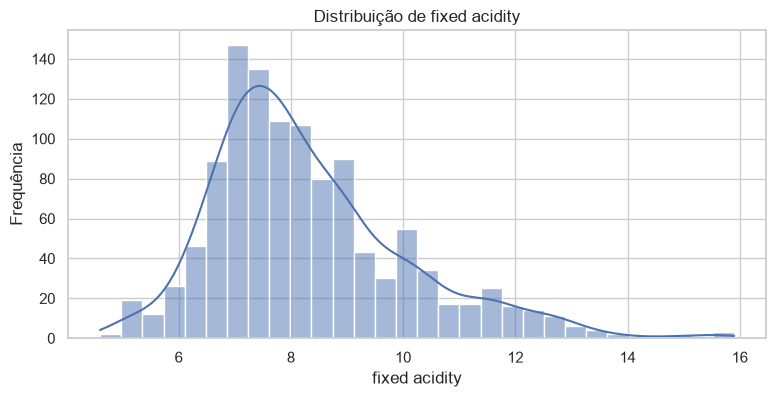

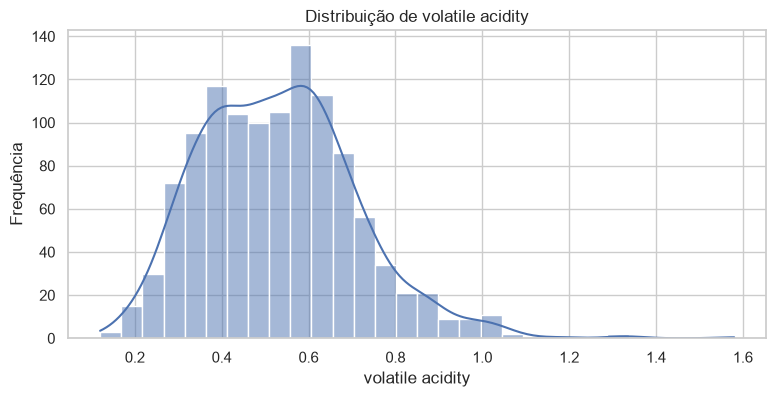

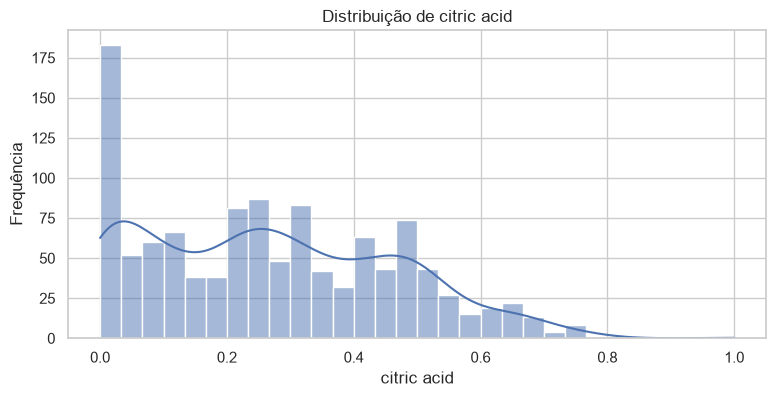

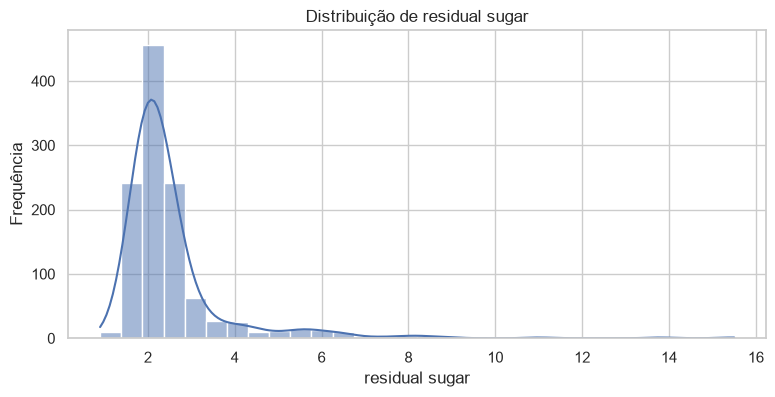

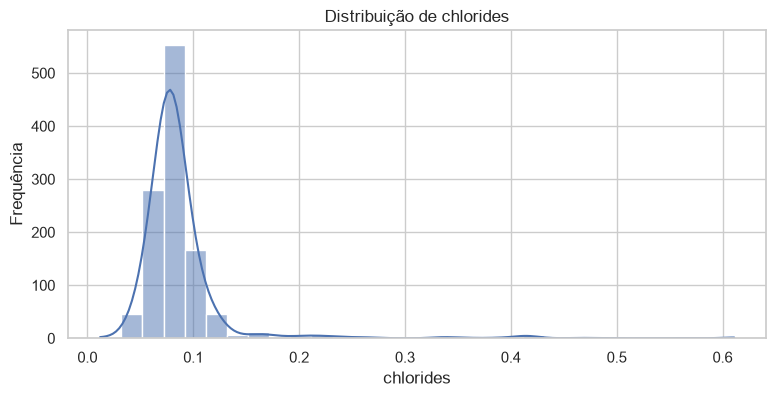

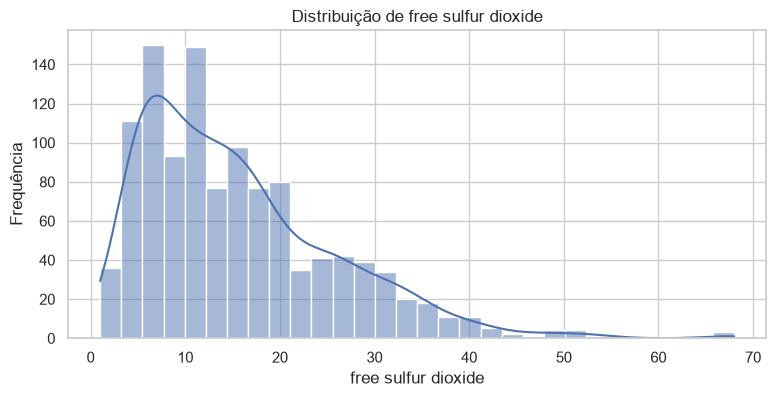

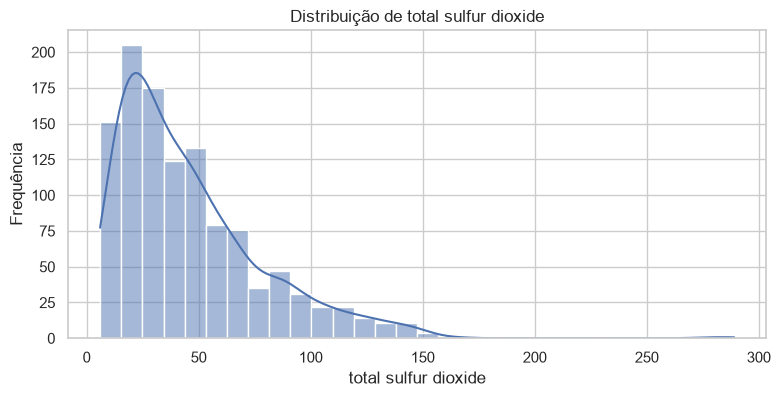

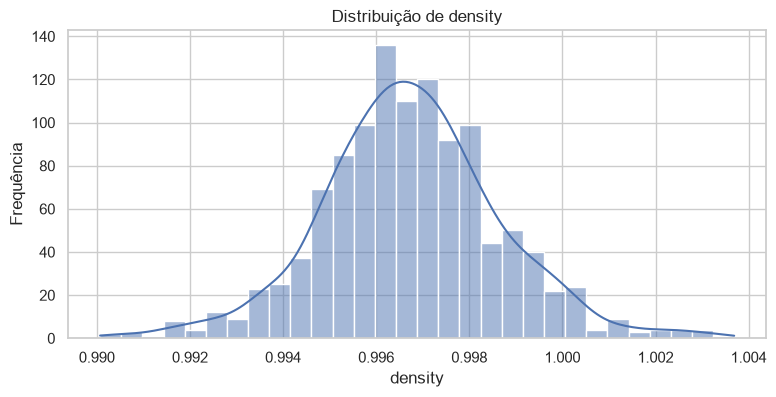

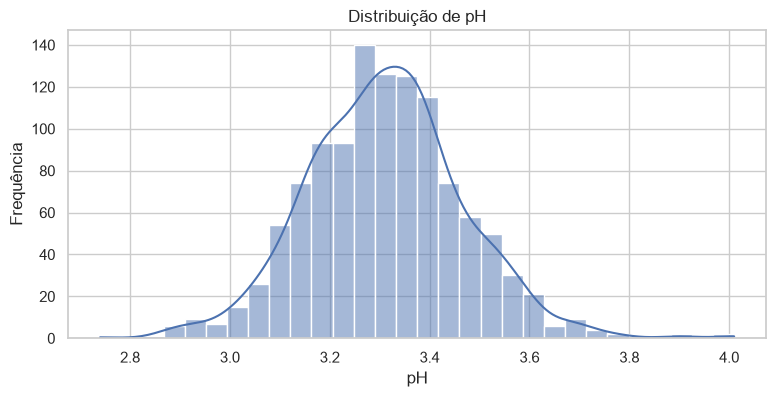

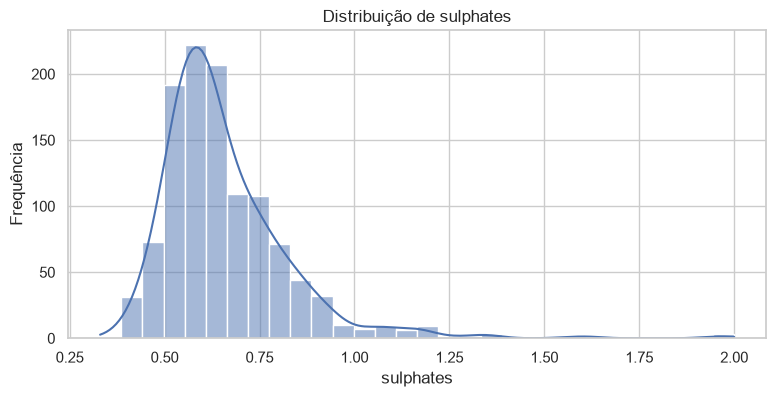

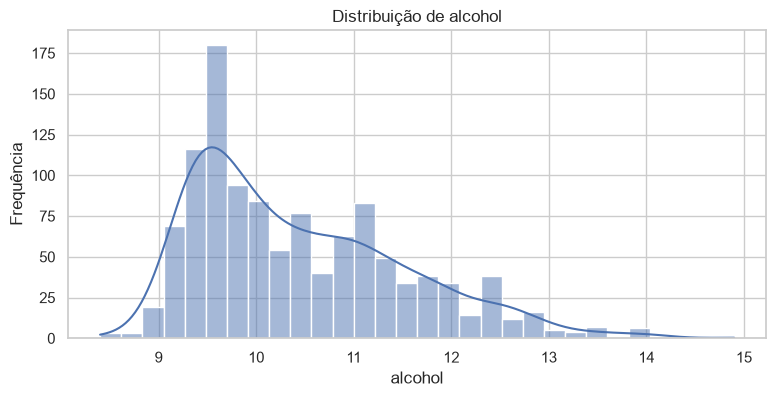

In [29]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in num_cols:
    if col != "quality" and col != "Id":
        plt.figure(figsize=(9, 4))
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"Distribuição de {col}")
        plt.xlabel(col)
        plt.ylabel("Frequência")
        plt.show()